# S03. Earth, Moon, and Sun

The earlier system notebooks used the star as every world's tidal host. In the Earth-Moon-Sun system, the Earth and Moon raise each other's tides and the Sun only provides insolation. Each world therefore has two orbits: one about its tidal host (for tides) and one about the star (for insolation).

This notebook makes the Earth and Moon a mutual pair and compares single-body and dual-body dissipation with the measured lunar recession and lengthening of the day. It then sweeps each body's obliquity and the Moon's orbital period to show where the orbit expands and where it contracts.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import au, year
from TidalPy.Structures import System, build_world

CM_PER_YEAR = 100.0 * year  # converts [m s-1] to [cm yr-1]
CENTURY = 100.0 * year  # [s]

# Bundled worlds: a star, a three-layer Earth, and a five-layer Moon fitted to its k2 and Q
sun = build_world("sol")
earth = build_world("earth_simple")
moon = build_world("luna")

# Both layered worlds use the rheology tide model, which needs a solved interior
earth.solve_eos(raise_on_fail=True)
moon.solve_eos(raise_on_fail=True)

for world in (earth, moon):
    print(f"{world.name:12} R = {world.radius / 1e3:7.1f} km   M = {world.mass:.4e} kg   "
          f"C/MR^2 = {world.moment_of_inertia_factor:.4f}")

Earth-Simple R =  6371.0 km   M = 5.9720e+24 kg   C/MR^2 = 0.3307
Luna         R =  1737.4 km   M = 7.3458e+22 kg   C/MR^2 = 0.3931


## Building the System

The Sun is added as the star, with no tidal host. The Earth is added with no host yet, since the Moon is not in the system. The Moon is added with the Earth as its host and carries the orbit. `set_tidal_host(earth, moon)` then makes the two a mutual pair.

A mutual pair shares one orbit, so the Earth has no semi-major axis of its own and reads the Moon's.

The bundled Moon spins at the observed 27.322 day sidereal rate, which matches the two-body period only to the precision of the orbital elements. Any mismatch adds a slow tidal mode (and TidalPy warns about a spin this close to, but not at, the mean motion), so `synchronous=True` sets the Moon's spin to its mean motion about the Earth.

In [2]:
system = System("Earth-Moon-Sun")
system.add_world(
    sun,
    is_star=True)  # Insolation source, not a tidal host
system.add_world(earth)  # The Moon's tidal host. Its own host is set below.
system.add_world(
    moon,
    tidal_host=earth,  # The Earth raises the Moon's tides
    semi_major_axis=3.84748e8,  # Moon about the Earth [m], not the 3.844e8 m distance from the mean sine parallax
    eccentricity=0.0549,
    synchronous=True)  # Spin = mean motion about the Earth
system.set_tidal_host(earth, moon)  # The Moon raises the Earth's tides in turn

for world in system:
    host = system.get_tidal_host(world)
    print(f"{world.name:12} tidal host: {host.name if host is not None else 'none':12} "
          f"mutual pair: {system.is_mutual_pair(world)}")
print(f"star: {system.star.name}")
print(f"Earth's orbit, read from the Moon: a = {system.get_semi_major_axis(earth):.4e} m, "
      f"e = {system.get_eccentricity(earth)}")
print(f"two-body orbital period: {2.0 * np.pi / system.calc_orbital_frequency(moon) / 86400.0:.3f} days, "
      f"Moon's spin period: {2.0 * np.pi / moon.spin_frequency / 86400.0:.3f} days")

Sol          tidal host: none         mutual pair: False
Earth-Simple tidal host: Luna         mutual pair: True
Luna         tidal host: Earth-Simple mutual pair: True
star: Sol
Earth's orbit, read from the Moon: a = 3.8475e+08 m, e = 0.0549
two-body orbital period: 27.322 days, Moon's spin period: 27.322 days


## Stellar Orbit and Insolation

The orbit about the star is set separately, with `set_stellar_semi_major_axis` and `set_stellar_eccentricity`, and is used only for insolation. Here both bodies orbit the Sun at 1 au with Earth's eccentricity. `calc_insolation_flux` returns the orbit-averaged flux \[W m$^{-2}$\] and `calc_equilibrium_temperature` the gray-body temperature \[K\] from each world's albedo and emissivity.

In [3]:
for world in (earth, moon):
    system.set_stellar_semi_major_axis(world, au)       # Orbit about the Sun [m]
    system.set_stellar_eccentricity(world, 0.0167)

print(f"{'world':12} {'albedo':>7} {'flux (W/m^2)':>13} {'T_eq (K)':>9}")
for world in (earth, moon):
    flux = system.calc_insolation_flux(world)
    temperature = system.calc_equilibrium_temperature(world)
    print(f"{world.name:12} {world.albedo:7.2f} {flux:13.1f} {temperature:9.1f}")

world         albedo  flux (W/m^2)  T_eq (K)
Earth-Simple    0.30        1361.4     254.6
Luna            0.12        1361.4     269.6


## Single-Body Evolution

`calc_world_evolution` solves the tides raised in one world and treats its host as a point mass. It returns that body's contribution to the orbital rates, its own spin rate, and its tidal heating \[W\].

The Earth rotates faster than the Moon orbits, so the Earth's tidal bulge leads the Moon. The bulge pulls the Moon forward, which raises the orbit (positive $da/dt$) and slows the Earth's spin. The synchronous Moon dissipates only through its eccentricity, which draws energy from the orbit and lowers it. The same tide spins the Moon up (positive $d\mathrm{spin}/dt$), toward the faster pseudo-synchronous rate of an eccentric orbit. The real Moon stays locked through the torque on its permanent, non-spherical figure, which this model does not include.

In [4]:
def length_of_day_rate(spin_frequency, dspin_dt):
    """Change in the length of day [ms per century] from a spin rate [rad s-1] and its derivative [rad s-2]."""
    return -2.0 * np.pi * dspin_dt / spin_frequency**2 * CENTURY * 1.0e3

print(f"{'dissipating body':16} {'heating (W)':>12} {'da/dt (cm/yr)':>14} {'de/dt (1/yr)':>13} "
      f"{'dspin/dt (rad/s^2)':>19}")
single = {}
for world in (earth, moon):
    single[world.name] = evolution = system.calc_world_evolution(world)
    print(f"{world.name:16} {evolution['tidal_heating']:12.3e} {evolution['da_dt'] * CM_PER_YEAR:14.4f} "
          f"{evolution['de_dt'] * year:13.3e} {evolution['dspin_dt']:19.3e}")

earth_single = single[earth.name]
print(f"\nEarth's length of day from the tide in the solid Earth: "
      f"{length_of_day_rate(earth.spin_frequency, earth_single['dspin_dt']):+.3f} ms per century")

dissipating body  heating (W)  da/dt (cm/yr)  de/dt (1/yr)  dspin/dt (rad/s^2)
Earth-Simple        1.530e+11         0.1870     4.120e-13          -2.717e-23
Luna                6.305e+08        -0.0542    -4.736e-12           4.607e-21

Earth's length of day from the tide in the solid Earth: +0.101 ms per century


## Dual-Body Evolution

`calc_pair_evolution` solves both bodies' tides on the shared orbit and sums their contributions to the orbital rates. The `world` and `host` entries hold each body's single-body result, so the combined rate is the sum of the two rows above. `energy_residual` checks that the heating in both bodies balances the loss of orbital and spin energy.

In [5]:
pair = system.calc_pair_evolution(moon)
earth_part = pair["worlds"][earth.name]  # Each body's own contribution, keyed by its name
moon_part = pair["worlds"][moon.name]

recession = pair["da_dt"] * CM_PER_YEAR
print(f"combined da/dt : {recession:+.4f} cm/yr  (Earth {earth_part['da_dt'] * CM_PER_YEAR:+.4f}, "
      f"Moon {moon_part['da_dt'] * CM_PER_YEAR:+.4f})")
print(f"combined de/dt : {pair['de_dt'] * year:+.3e} 1/yr  (Earth {earth_part['de_dt'] * year:+.3e}, "
      f"Moon {moon_part['de_dt'] * year:+.3e})")
print(f"Earth heating  : {earth_part['tidal_heating']:.3e} W")
print(f"Moon heating   : {moon_part['tidal_heating']:.3e} W")
print(f"total heating  : {pair['tidal_heating_total']:.3e} W")
print(f"relative energy residual: {pair['energy_residual'] / pair['tidal_heating_total']:.1e}")

print(f"\nlunar laser ranging: 3.83 cm/yr, model: {recession:.3f} cm/yr "
      f"(ratio {3.83 / recession:.0f})")

combined da/dt : +0.1328 cm/yr  (Earth +0.1870, Moon -0.0542)
combined de/dt : -4.324e-12 1/yr  (Earth +4.120e-13, Moon -4.736e-12)
Earth heating  : 1.530e+11 W
Moon heating   : 6.305e+08 W
total heating  : 1.536e+11 W
relative energy residual: 0.0e+00

lunar laser ranging: 3.83 cm/yr, model: 0.133 cm/yr (ratio 29)


The model's recession is far below the 3.83 cm yr$^{-1}$ measured by lunar laser ranging (Williams and Boggs 2016), and its length-of-day change is a small fraction of the approx. 2.4 ms per century attributed to tides. This is expected. Most of Earth's present tidal dissipation (approx. 3.7 TW in total) occurs in its oceans, which this model does not have. The solid-Earth heating here, approx. 0.15 TW, is close to the solid-body share inferred from satellite tracking (Ray et al. 2001). Further simplifications:

- The solar tide on the Earth, which adds roughly a fifth to the spin-down torque, is not included.
- Only harmonic degree $l = 2$ is used, with the default eccentricity truncation.
- Both obliquities are zero so far. The next section changes that.

## Obliquity Tides

A world whose spin axis is tilted relative to its orbit normal feels an additional tide as the host moves above and below its equator. These terms require an obliquity truncation. `obliquity_truncation="gen"` uses the general form, valid at any angle. Levels 2 and 4 keep the heating through $I^2$ and $I^4$ and are faster at small tilts (see notebook P11). 0 (`"off"`) ignores obliquity. `set_obliquity` \[rad\] sets the tilt.

The sweep below tilts one body at a time from 0 to 90 degrees, holding the other at zero. The Moon's obliquity to its orbit is about 6.7 degrees. The Earth's equator is tilted approx. 18 to 29 degrees from the Moon's orbit plane.

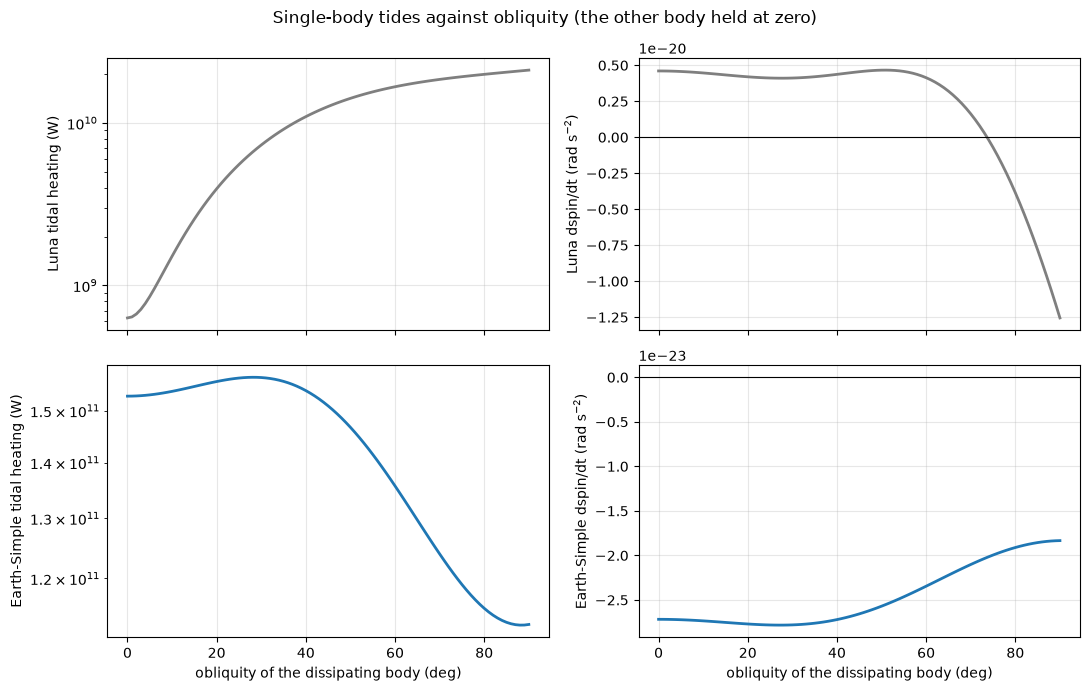

Moon's dspin/dt turns negative at 74 deg
largest change of the Earth from zero obliquity: heating 26%, spin-down rate 33%
Moon heating at 6.68 deg : 1.028e+09 W (1.63 times the zero-obliquity value)
Earth heating at 23.4 deg: 1.565e+11 W
combined da/dt           : +0.1213 cm/yr
Earth's length of day    : +0.104 ms per century


In [6]:
for world in (earth, moon):
    world.set_tide_config(
        eccentricity_truncation=6,  # Heating terms through e^6
        obliquity_truncation="gen")  # General obliquity functions, valid at any angle

obliquities_deg = np.linspace(0.0, 90.0, 91)
sweep = {earth.name: {"heating": [], "dspin_dt": []}, moon.name: {"heating": [], "dspin_dt": []}}
for world in (earth, moon):
    for obliquity_deg in obliquities_deg:
        world.set_obliquity(np.radians(obliquity_deg))
        evolution = system.calc_world_evolution(world)
        sweep[world.name]["heating"].append(evolution["tidal_heating"])
        sweep[world.name]["dspin_dt"].append(evolution["dspin_dt"])
    world.set_obliquity(0.0)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for row, (world, color) in enumerate([(moon, "tab:gray"), (earth, "tab:blue")]):
    axes[row, 0].semilogy(obliquities_deg, sweep[world.name]["heating"], color=color, lw=2)
    axes[row, 0].set_ylabel(f"{world.name} tidal heating (W)")
    axes[row, 1].plot(obliquities_deg, sweep[world.name]["dspin_dt"], color=color, lw=2)
    axes[row, 1].axhline(0.0, color="k", lw=0.8)
    axes[row, 1].set_ylabel(f"{world.name} dspin/dt (rad s$^{{-2}}$)")
for ax in axes.ravel():
    ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("obliquity of the dissipating body (deg)")
fig.suptitle("Single-body tides against obliquity (the other body held at zero)")
fig.tight_layout()
plt.show()

moon_spin_rate = np.array(sweep[moon.name]["dspin_dt"])
earth_heating = np.array(sweep[earth.name]["heating"])
earth_spin_rate = np.array(sweep[earth.name]["dspin_dt"])
print(f"Moon's dspin/dt turns negative at {obliquities_deg[np.argmax(moon_spin_rate < 0.0)]:.0f} deg")
heating_change = np.max(np.abs(earth_heating / earth_heating[0] - 1.0))
spin_rate_change = np.max(np.abs(earth_spin_rate / earth_spin_rate[0] - 1.0))
print(f"largest change of the Earth from zero obliquity: heating {heating_change:.0%}, "
      f"spin-down rate {spin_rate_change:.0%}")

# Present-day tilts relative to the Earth-Moon orbit plane
moon.set_obliquity(np.radians(6.68))
earth.set_obliquity(np.radians(23.4))
pair_tilted = system.calc_pair_evolution(moon)
moon_tilted = pair_tilted["worlds"][moon.name]
earth_tilted = pair_tilted["worlds"][earth.name]
print(f"Moon heating at 6.68 deg : {moon_tilted['tidal_heating']:.3e} W "
      f"({moon_tilted['tidal_heating'] / moon_part['tidal_heating']:.2f} times the zero-obliquity value)")
print(f"Earth heating at 23.4 deg: {earth_tilted['tidal_heating']:.3e} W")
print(f"combined da/dt           : {pair_tilted['da_dt'] * CM_PER_YEAR:+.4f} cm/yr")
print(f"Earth's length of day    : "
      f"{length_of_day_rate(earth.spin_frequency, earth_tilted['dspin_dt']):+.3f} ms per century")

The Moon's heating rises steeply with obliquity, from about $6 \times 10^{8}$ W at zero to about $2 \times 10^{10}$ W at 90 degrees. At its real tilt of 6.68 degrees it is already 1.6 times the eccentricity-only heating. The torque on the synchronous Moon changes little until large tilts and reverses sign near 74 degrees. The Earth's heating changes by at most 26 percent and its spin-down rate by at most 33 percent over the full range, both falling at large tilts, since its tide is set mostly by its fast rotation. With both present-day tilts, the combined recession and length-of-day change stay close to their zero-obliquity values.

## Inside and Outside the Synchronous Orbit

The sign of the Earth's contribution to $da/dt$ depends on whether the Moon orbits faster or slower than the Earth rotates. Inside the synchronous orbit (orbital period shorter than the Earth's sidereal day) the Earth's bulge trails the Moon and the orbit contracts. Outside it the orbit expands. The sweep below moves the Moon from 3 to 70 Earth radii, keeping it synchronous with `set_synchronous_rotation`, at the present Earth rotation and obliquities, and plots the pair's combined rates against the Moon's orbital period.

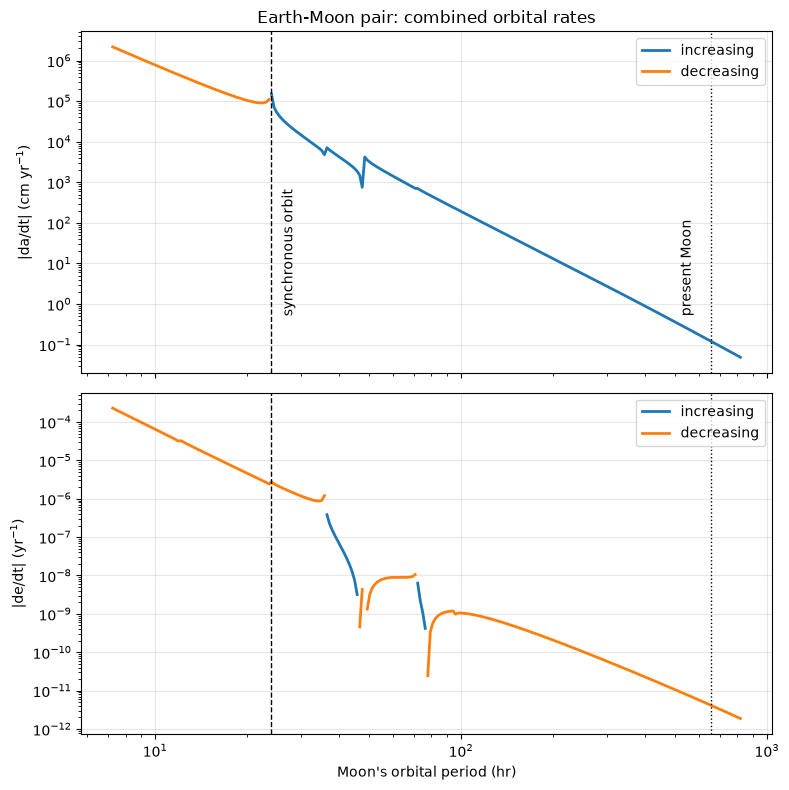

sweep: orbital periods from 7.3 hr to 34.1 days
Earth's sidereal day: 23.93 hr
da/dt changes sign between 23.54 and 24.00 hr (6.57 to 6.66 Earth radii)


In [7]:
present_semi_major_axis = system.get_semi_major_axis(moon)
semi_major_axes = np.logspace(np.log10(3.0), np.log10(70.0), 250) * earth.radius  # [m]

periods_hr = np.empty_like(semi_major_axes)
da_dt = np.empty_like(semi_major_axes)
de_dt = np.empty_like(semi_major_axes)
for i, semi_major_axis in enumerate(semi_major_axes):
    system.set_semi_major_axis(moon, semi_major_axis)
    orbital_frequency = system.set_synchronous_rotation(moon)  # Keeps the Moon synchronous; returns its spin [rad s-1]
    pair_sweep = system.calc_pair_evolution(moon)
    periods_hr[i] = 2.0 * np.pi / orbital_frequency / 3600.0
    da_dt[i] = pair_sweep["da_dt"] * CM_PER_YEAR
    de_dt[i] = pair_sweep["de_dt"] * year

# Restore the present orbit
system.set_semi_major_axis(moon, present_semi_major_axis)
system.set_synchronous_rotation(moon)

sidereal_day_hr = 2.0 * np.pi / earth.spin_frequency / 3600.0
present_period_hr = 2.0 * np.pi / moon.spin_frequency / 3600.0

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
for ax, rate, label in [(axes[0], da_dt, "|da/dt| (cm yr$^{-1}$)"), (axes[1], de_dt, "|de/dt| (yr$^{-1}$)")]:
    ax.loglog(periods_hr, np.where(rate > 0.0, rate, np.nan), color="tab:blue", lw=2, label="increasing")
    ax.loglog(periods_hr, np.where(rate < 0.0, -rate, np.nan), color="tab:orange", lw=2, label="decreasing")
    ax.axvline(sidereal_day_hr, color="k", ls="--", lw=1)
    ax.axvline(present_period_hr, color="k", ls=":", lw=1)
    ax.set_ylabel(label)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
axes[0].text(sidereal_day_hr * 1.08, 0.5, "synchronous orbit", rotation=90, va="bottom")
axes[0].text(present_period_hr * 0.88, 0.5, "present Moon", rotation=90, va="bottom", ha="right")
axes[1].set_xlabel("Moon's orbital period (hr)")
axes[0].set_title("Earth-Moon pair: combined orbital rates")
fig.tight_layout()
plt.show()

print(f"sweep: orbital periods from {periods_hr[0]:.1f} hr to {periods_hr[-1] / 24.0:.1f} days")
print(f"Earth's sidereal day: {sidereal_day_hr:.2f} hr")
for i in np.where(np.diff(np.sign(da_dt)) != 0)[0]:
    print(f"da/dt changes sign between {periods_hr[i]:.2f} and {periods_hr[i + 1]:.2f} hr "
          f"({semi_major_axes[i] / earth.radius:.2f} to {semi_major_axes[i + 1] / earth.radius:.2f} Earth radii)")

The orbit contracts inside the synchronous orbit, near 6.6 Earth radii, and expands outside it. The magnitude falls steeply with distance, since the tidal torque scales as $a^{-6}$ before any change in the interior's frequency response. The narrow steps near orbital periods of 1.5, 2, and 3 sidereal days are where one tidal mode's forcing frequency, $(2 - 2p + q)\,n - m\,\Omega$, passes through zero. Near zero frequency the viscous mantle dissipates strongly, with a sign that follows the mode's frequency. That mode's contribution therefore reverses over a range of periods much narrower than the sweep's spacing.

The eccentricity rate changes sign several times between the synchronous orbit and about 3 sidereal days, as individual modes change sign and the balance between the Earth's and the Moon's contributions shifts. At the present distance the Moon's own dissipation dominates this solid-body model, and the eccentricity decays. Lunar laser ranging instead measures a slowly growing eccentricity (Williams and Boggs 2016), mostly from the tides in the Earth's oceans, which this model lacks. These are instantaneous rates for the present Earth rotation. A history of the Earth-Moon system would integrate them in time, evolving the Earth's spin and the Moon's orbit together.